# FZI-AURA - Sensor Data and PCD Fields

This notebook shows how to load camera, lidar, and radar data through lazy frame handles. It also highlights that PCD fields are file-specific and should be inspected at runtime. Each section selects a frame that explicitly contains its sensor and skips cleanly when the corresponding layer is absent. Camera, LiDAR, and radar sections use `camera_keyframes`, `lidar_motion_compensated_keyframes`, and `radar_keyframes`, respectively.

In [ ]:
# If fzi_aura or the plotting dependencies are not available in this notebook's current Python kernel,
# uncomment and run the next line before continuing. %pip targets this kernel.
# %pip install "fzi-aura[vis]"

In [10]:
import os
from pathlib import Path

import numpy as np

from fzi_aura import FZIAURADataset

os.environ["FZI_AURA_ROOT"] = "/data/fzi-aura"

DATASET_ROOT = Path(
    os.environ.get(
        "FZI_AURA_ROOT",
        "/path/to/dataset_export",
    )
)

dataset = FZIAURADataset(DATASET_ROOT, split="train")
scene = dataset[-50]

## 1. Camera Image

In [11]:
camera_frames = scene.frames(
    sample_filter="sensor_available",
    require_cameras=["front_medium"],
)
camera_frame = camera_frames[0] if len(camera_frames) else None
if camera_frame is None:
    print("Skipped: camera frames are not downloaded.")
else:
    camera_id = "front_medium"
    image = camera_frame.load_camera(camera_id)
    print(camera_id, image.shape, image.dtype)

front_medium (1200, 1920, 3) uint8


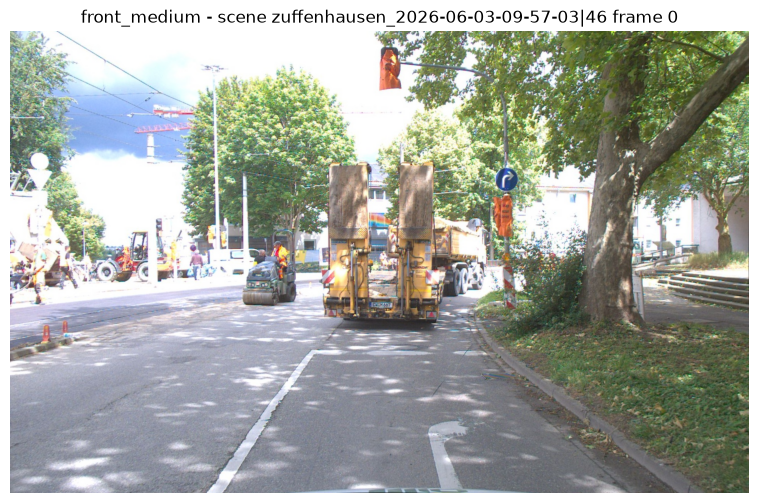

In [12]:
if camera_frame is not None:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.imshow(image)
    plt.title(
        f"{camera_id} - scene {camera_frame.scene_id} frame {camera_frame.frame_index}"
    )
    plt.axis("off")
    plt.show()

## 2. Lidar Point Cloud

Semantic labels can be paired with `motion_compensated` or `raw` lidar. Raw and motion-compensated clouds can have different fields.

In [13]:
lidar_frames = scene.frames(
    sample_filter="sensor_available",
    require_lidars=["top_left"],
)
lidar_frame = lidar_frames[0] if len(lidar_frames) else None
if lidar_frame is None:
    print("Skipped: lidar_motion_compensated_keyframes with top_left is not installed.")
else:
    lidar_id = "top_left"
    path = lidar_frame.lidar_path(lidar_id, stage="motion_compensated")
    # print(path)

    cloud = lidar_frame.load_lidar(lidar_id, stage="motion_compensated")
    print(f"points={len(cloud):,}, xyz={cloud.xyz.shape}, fields={cloud.field_names}")
    for name in cloud.field_names:
        print(
            f"{name:<20} dtype={cloud.field(name).dtype} shape={cloud.field(name).shape}"
        )

points=77,891, xyz=(77891, 3), fields=('x', 'y', 'z', 't', 'reflectivity', 'ring', 'range')
x                    dtype=float32 shape=(77891,)
y                    dtype=float32 shape=(77891,)
z                    dtype=float32 shape=(77891,)
t                    dtype=uint32 shape=(77891,)
reflectivity         dtype=uint16 shape=(77891,)
ring                 dtype=uint16 shape=(77891,)
range                dtype=uint32 shape=(77891,)


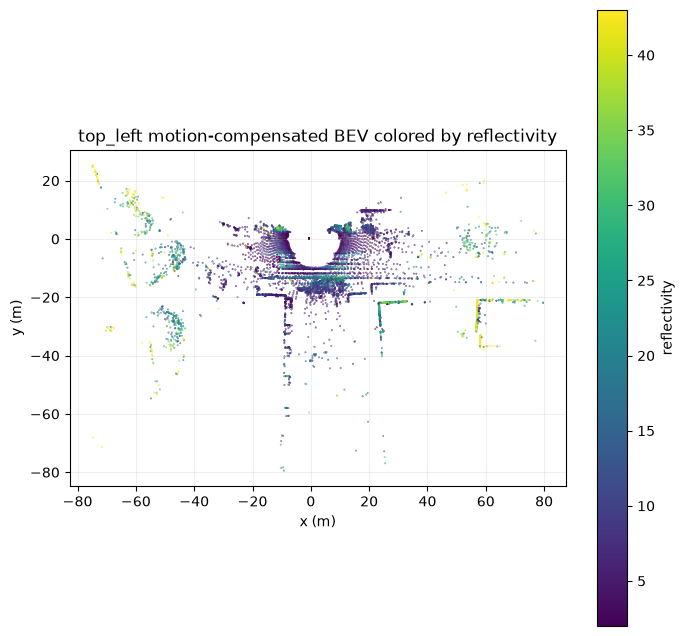

In [14]:
if lidar_frame is not None:
    import matplotlib.pyplot as plt

    xyz = cloud.xyz
    keep = (np.abs(xyz[:, 0]) < 80) & (np.abs(xyz[:, 1]) < 80)
    sample_idx = np.flatnonzero(keep)[::10]
    sample = xyz[sample_idx]

    if cloud.has_field("reflectivity"):
        color_values = cloud.field("reflectivity")[sample_idx]
        color_label = "reflectivity"
    else:
        color_values = sample[:, 2]
        color_label = "z (m)"

    finite_values = color_values[np.isfinite(color_values)]
    vmin, vmax = np.percentile(finite_values, [5, 95])

    plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        sample[:, 0],
        sample[:, 1],
        s=0.1,
        c=color_values,
        cmap="viridis",
        vmin=vmin,  # clip color scale for visibility
        vmax=vmax,
    )
    plt.gca().set_aspect("equal")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(f"{lidar_id} motion-compensated BEV colored by {color_label}")
    plt.colorbar(scatter, label=color_label)
    plt.grid(True, alpha=0.2)
    plt.show()

## 3. Radar Point Cloud

In [17]:
# if the selected scene in your dataset does not contain radar data, select a different scene by filtering for scenes or frames with Radar data.
# radar_frames = dataset.as_frames(
#   require_radars=["front_left"],
# )

radar_frames = scene.frames(
    sample_filter="sensor_available",
    require_radars=["front_left"],
)
radar_frame = radar_frames[0] if len(radar_frames) else None
if radar_frame is None:
    print("Skipped: radar_keyframes with front_left is not installed.")
else:
    radar_id = "front_left"
    radar = radar_frame.load_radar(radar_id)
    print(f"{radar_id}: points={len(radar)}, fields={radar.field_names}")
    for name in radar.field_names:
        print(
            f"{name:<20} dtype={radar.field(name).dtype} shape={radar.field(name).shape}"
        )

front_left: points=387, fields=('x', 'y', 'z', 'rcs', 'elevation_angle', 'range_rate')
x                    dtype=float32 shape=(387,)
y                    dtype=float32 shape=(387,)
z                    dtype=float32 shape=(387,)
rcs                  dtype=int8 shape=(387,)
elevation_angle      dtype=float32 shape=(387,)
range_rate           dtype=float32 shape=(387,)


## 4. Field-Safe Access Pattern

Use `has_field` before consuming optional point attributes such as `velocity`.

In [18]:
if lidar_frame is not None:
    feature_names = ["x", "y", "z", "reflectivity", "velocity"]
    features = cloud.to_numpy(feature_names, missing="nan")
    print(feature_names)
    print(features.shape)
    print("velocity present:", cloud.has_field("velocity"))

['x', 'y', 'z', 'reflectivity', 'velocity']
(77891, 5)
velocity present: False
